In [1]:
# ==========================================
# Import Libraries
# ==========================================

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay

)

In [2]:
# ==========================================
# Experiment Paths
# ==========================================

EXPERIMENT_DIR = Path("../experiments/E02_FeatureSelection")

FIGURES_DIR = EXPERIMENT_DIR / "figures"

MODELS_DIR = EXPERIMENT_DIR / "trained_models"

CM_DIR = EXPERIMENT_DIR / "confusion_matrices"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR.mkdir(parents=True, exist_ok=True)

CM_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ==========================================
# Load Dataset
# ==========================================

data_path = "../data/cicids2017_cleaned.csv"

chunks = pd.read_csv(

    data_path,

    chunksize=100000

)

chunk = next(chunks)

print(chunk.shape)

print(chunk["Attack Type"].value_counts())

(100000, 53)
Attack Type
Normal Traffic    84992
Port Scanning     15008
Name: count, dtype: int64


In [4]:
# ==========================================
# Balanced Sampling
# ==========================================

normal_data = []

attack_data = []

chunks = pd.read_csv(

    data_path,

    chunksize=100000

)

for chunk in chunks:

    chunk.columns = chunk.columns.str.strip()

    normal = chunk[
        chunk["Attack Type"] == "Normal Traffic"
    ]

    attack = chunk[
        chunk["Attack Type"] != "Normal Traffic"
    ]

    if len(normal) > 0:

        normal_data.append(

            normal.sample(

                min(len(normal),500),

                random_state=42

            )

        )

    if len(attack) > 0:

        attack_data.append(

            attack.sample(

                min(len(attack),500),

                random_state=42

            )

        )

    if (

        len(normal_data)*500 >= 50000

        and

        len(attack_data)*500 >= 50000

    ):

        break

df_normal = pd.concat(normal_data)

df_attack = pd.concat(attack_data)

df_final = pd.concat(

    [df_normal,df_attack]

)

df_final = df_final.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)

print(df_final.shape)

print(df_final["Attack Type"].value_counts())

(21812, 53)
Attack Type
Normal Traffic    13000
DoS                3006
Brute Force        2499
Port Scanning      1331
DDoS               1000
Bots                806
Web Attacks         170
Name: count, dtype: int64


In [5]:
# ==========================================
# Label Encoding
# ==========================================

encoder = LabelEncoder()

df_final["Attack Type Encoded"] = encoder.fit_transform(

    df_final["Attack Type"]

)

joblib.dump(

    encoder,

    EXPERIMENT_DIR/"label_encoder.pkl"

)

print("Label Encoder Saved.")

Label Encoder Saved.


In [6]:
# ==========================================
# Features and Target
# ==========================================

X = df_final.drop(

    ["Attack Type","Attack Type Encoded"],

    axis=1

)

y = df_final["Attack Type Encoded"]

joblib.dump(

    list(X.columns),

    EXPERIMENT_DIR/"feature_names.pkl"

)

print(X.shape)

(21812, 52)


In [7]:
# ==========================================
# Train Test Split
# ==========================================

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(15268, 52)
(6544, 52)


In [8]:
# ==========================================
# Feature Importance
# ==========================================

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(

    X_train,

    y_train

)

feature_importance_df = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

feature_importance_df.sort_values(

    by="Importance",

    ascending=False,

    inplace=True

)

feature_importance_df.reset_index(

    drop=True,

    inplace=True

)

feature_importance_df.head(20)

,Feature,Importance
0,Destination Port,0.126521
1,Bwd Packet Length Std,0.048684
2,Bwd Packet Length Max,0.038557
3,Bwd Packet Length Mean,0.036183
4,Bwd Header Length,0.035131
5,Init_Win_bytes_forward,0.030981
6,Packet Length Std,0.030735
7,Total Length of Fwd Packets,0.029639
8,Packet Length Variance,0.029338
9,Subflow Fwd Bytes,0.026715


In [9]:
# ==========================================
# Save Feature Importance
# ==========================================

feature_importance_df.to_csv(

    EXPERIMENT_DIR/"feature_importance.csv",

    index=False

)

feature_importance_df.to_excel(

    EXPERIMENT_DIR/"feature_importance.xlsx",

    index=False

)

print("Feature Importance Saved.")

Feature Importance Saved.


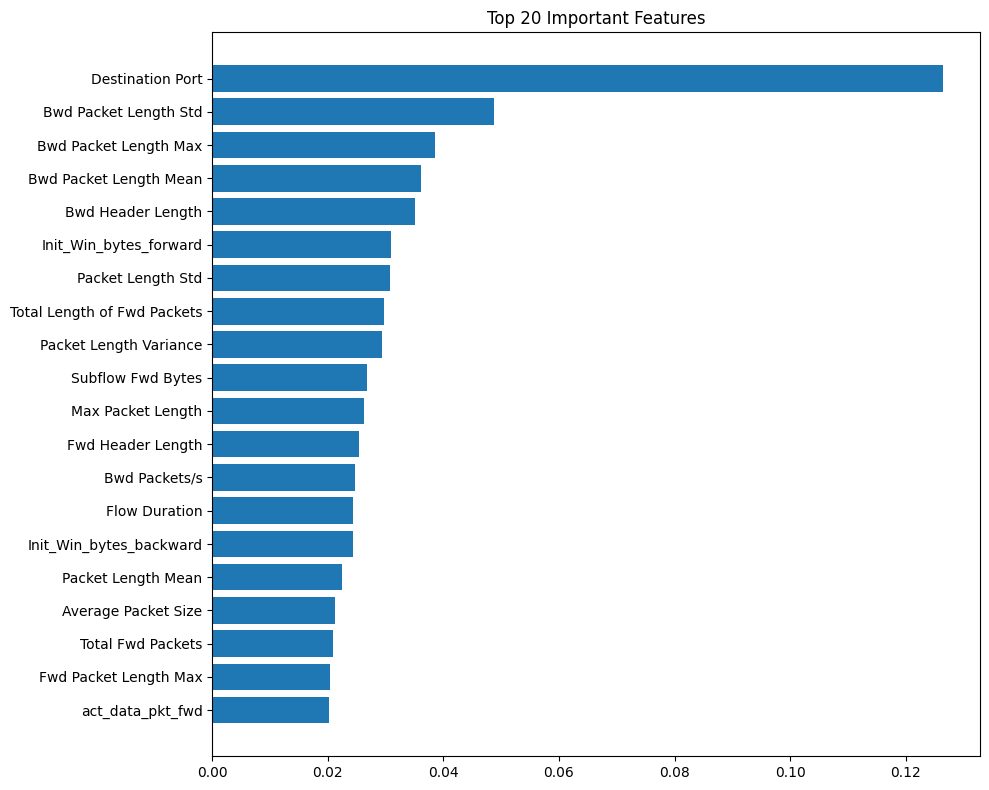

In [10]:
# ==========================================
# Feature Importance Figure
# ==========================================

plt.figure(figsize=(10,8))

plt.barh(

    feature_importance_df["Feature"].head(20),

    feature_importance_df["Importance"].head(20)

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR/"feature_importance_plot.png",

    dpi=300

)

plt.show()

In [11]:
# ==========================================
# Create Feature Sets
# ==========================================

feature_sets = {

    "All Features":

        list(X_train.columns),

    "Top 30":

        feature_importance_df["Feature"].head(30).tolist(),

    "Top 25":

        feature_importance_df["Feature"].head(25).tolist(),

    "Top 20":

        feature_importance_df["Feature"].head(20).tolist(),

    "Top 15":

        feature_importance_df["Feature"].head(15).tolist()

}

for name,features in feature_sets.items():

    print(name,len(features))

All Features 52
Top 30 30
Top 25 25
Top 20 20
Top 15 15


In [12]:
# ==========================================
# Save Selected Features
# ==========================================

selected_features_df = pd.DataFrame({

    "Top 30":

        pd.Series(feature_sets["Top 30"]),

    "Top 25":

        pd.Series(feature_sets["Top 25"]),

    "Top 20":

        pd.Series(feature_sets["Top 20"]),

    "Top 15":

        pd.Series(feature_sets["Top 15"])

})

selected_features_df.to_csv(

    EXPERIMENT_DIR/"selected_features.csv",

    index=False

)

selected_features_df.to_excel(

    EXPERIMENT_DIR/"selected_features.xlsx",

    index=False

)

print("Selected Features Saved.")

Selected Features Saved.


In [13]:
# ==========================================
# XGBoost Feature Selection Experiment
# ==========================================

import time
import joblib
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score

)

N_RUNS = 5

results = []

trained_models = {}

for feature_set_name, selected_features in feature_sets.items():

    print("="*60)
    print(feature_set_name)
    print("="*60)

    X_train_subset = X_train[selected_features]

    X_test_subset = X_test[selected_features]

    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    training_times = []
    prediction_times = []

    last_model = None

    for run in range(N_RUNS):

        model = XGBClassifier(

            eval_metric="mlogloss",

            random_state=42 + run

        )

        start_train = time.time()

        model.fit(

            X_train_subset,

            y_train

        )

        train_time = time.time() - start_train

        start_pred = time.time()

        y_pred = model.predict(

            X_test_subset

        )

        pred_time = time.time() - start_pred

        accuracy_list.append(

            accuracy_score(y_test,y_pred)

        )

        precision_list.append(

            precision_score(

                y_test,

                y_pred,

                average="weighted"

            )

        )

        recall_list.append(

            recall_score(

                y_test,

                y_pred,

                average="weighted"

            )

        )

        f1_list.append(

            f1_score(

                y_test,

                y_pred,

                average="weighted"

            )

        )

        training_times.append(train_time)

        prediction_times.append(pred_time)

        last_model = model

    trained_models[feature_set_name] = last_model

    filename = (

        feature_set_name

        .lower()

        .replace(" ","_")

        + ".pkl"

    )

    joblib.dump(

        last_model,

        MODELS_DIR / filename

    )

    results.append({

        "Feature Set":feature_set_name,

        "Number of Features":len(selected_features),

        "Mean Accuracy":np.mean(accuracy_list),

        "Mean Precision":np.mean(precision_list),

        "Mean Recall":np.mean(recall_list),

        "Mean F1-score":np.mean(f1_list),

        "Mean Training Time (s)":np.mean(training_times),

        "Mean Prediction Time (s)":np.mean(prediction_times)

    })

results_df = pd.DataFrame(results)

results_df.sort_values(

    by="Number of Features",

    ascending=False,

    inplace=True

)

results_df.reset_index(

    drop=True,

    inplace=True

)

results_df

All Features
Top 30
Top 25
Top 20
Top 15


,Feature Set,Number of Features,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-score,Mean Training Time (s),Mean Prediction Time (s)
0,All Features,52,0.997097,0.997102,0.997097,0.997098,2.913354,0.054150
1,Top 30,30,0.997097,0.997108,0.997097,0.997100,1.742138,0.040749
2,Top 25,25,0.996180,0.996212,0.996180,0.996192,1.592278,0.045101
3,Top 20,20,0.995263,0.995266,0.995263,0.995263,1.342564,0.041147
4,Top 15,15,0.995416,0.995419,0.995416,0.995416,1.235815,0.043418


In [14]:
# ==========================================
# Save Results
# ==========================================

results_df.to_csv(

    EXPERIMENT_DIR/

    "feature_selection_results.csv",

    index=False

)

results_df.to_excel(

    EXPERIMENT_DIR/

    "metrics_table.xlsx",

    index=False

)

print("Results Saved Successfully.")

Results Saved Successfully.


In [15]:
# ==========================================
# Generate Figures
# ==========================================

import matplotlib.pyplot as plt

metrics = [

    "Mean Accuracy",

    "Mean Precision",

    "Mean Recall",

    "Mean F1-score",

    "Mean Training Time (s)",

    "Mean Prediction Time (s)"

]

filenames = {

    "Mean Accuracy":

        "accuracy_comparison.png",

    "Mean Precision":

        "precision_comparison.png",

    "Mean Recall":

        "recall_comparison.png",

    "Mean F1-score":

        "f1_score_comparison.png",

    "Mean Training Time (s)":

        "training_time_comparison.png",

    "Mean Prediction Time (s)":

        "prediction_time_comparison.png"

}

for metric in metrics:

    plt.figure(figsize=(8,5))

    plt.bar(

        results_df["Feature Set"],

        results_df[metric]

    )

    plt.title(metric)

    plt.ylabel(metric)

    plt.tight_layout()

    plt.savefig(

        FIGURES_DIR/

        filenames[metric],

        dpi=300

    )

    plt.close()

print("Figures Saved.")

Figures Saved.


In [16]:
# ==========================================
# Generate Confusion Matrices
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay

for feature_set_name, model in trained_models.items():

    selected_features = feature_sets[feature_set_name]

    y_pred = model.predict(

        X_test[selected_features]

    )

    disp = ConfusionMatrixDisplay.from_predictions(

        y_test,

        y_pred,

        cmap="Blues",

        xticks_rotation=45

    )

    plt.title(feature_set_name)

    filename = (

        feature_set_name

        .lower()

        .replace(" ","_")

        + "_cm.png"

    )

    plt.savefig(

        CM_DIR/filename,

        dpi=300,

        bbox_inches="tight"

    )

    plt.close()

print("Confusion Matrices Saved.")

Confusion Matrices Saved.
